# SOCIAL NETWORK ANALYSIS
### Author: Greatness Okeremeta 

**Overview:**

This project investigates the social network structure within the Facebook dataset. By constructing a graph of users, the project explores the network's fundamental structure, computes its characteristics, estimates edge betweenness centrality, and compares two community detection algorithms: Louvain Modularity & Label Propagation.

**Dataset:** https://snap.stanford.edu/data/ego-Facebook.html

### Setup

In [1]:
# Import necessary libraries
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [2]:
# Set constants
DATASET_PATH = Path("data/facebook_combined.txt")
OUTPUT_DIR = Path("outputs")
CENTRALITY_PLOT_PATH = OUTPUT_DIR / "edge_betweenness_histogram.png"
COMMUNITY_PLOT_PATH = OUTPUT_DIR / "network_visualisations.png"
RANDOM_SEED = 42

### Network Construction and Characteristics

The Facebook social network will be loaded from the edge list. A function will be defined to compute and display the fundamental characteristics:
- **Nodes:** The number of users in the network.
- **Edges:** The number of connections (friendships).
- **Density:** A measure of how close the network is to being complete. A low density suggests a sparse network.
- **Average Degree:** The average number of friends per user.

In [3]:
# Function to load network and compute characteristics
def load_and_characterise_network(filepath: Path) -> nx.Graph | None:
    """
    A function to load a graph from an edge list file and print its basic characteristics.

    Arguments:
        filepath: Path to the edge list file.

    Returns:
        The constructed NetworkX graph, or None if the file was not found.
    """
    try:
        G = nx.read_edgelist(filepath.as_posix(), nodetype=int)
    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return None

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    avg_degree = 2 * num_edges / num_nodes

    # Calculate network characteristics
    print("--- Basic Network Characteristics ---")
    print(f"Nodes: {num_nodes}")
    print(f"Edges: {num_edges}")
    print(f"Density: {density:.5f}")
    print(f"Average Degree: {avg_degree:.3f}\n")

    return G

### Edge Centrality Analysis
The edge betweenness centrality is calculated here. This metric identifies the edges are important bridges connecting different parts of the network. A high score means an edge lies on many shortest paths between other nodes.

**Note on Approximation:** For a graph of this size, calculating exact betweenness centrality is computationally intensive. Therefore, an approximation based on a random sample of `k` nodes is used. It provides an efficient estimate.

In [4]:
# Function for Centrality Analysis

def calculate_edge_centrality(G: nx.Graph, save_path: Path, sample_fraction: float = 0.05, seed: int = RANDOM_SEED) -> dict:
    """
    A function to calculate and plot the distribution of edge centrality.

    Arguments:
        G: The network graph.
        save_path: Path to save the output histogram.
        sample_fraction: Fraction of nodes used as centrality sample sources.
        seed: Random seed for reproducibility.

    Returns:
        Dict mapping each edge to its estimated betweenness centrality.
    """
    if G is None:
        print("Graph not loaded. Centrality analysis can't be done!")
        return {}

    print("--- Calculating Edge Betweenness ---")

    k = max(1, int(G.number_of_nodes() * sample_fraction))
    rng = random.Random(seed)
    edge_bc = nx.edge_betweenness_centrality(G, k=k, seed=rng)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.hist(edge_bc.values(), bins=60)
    plt.title("Distribution of Edge Betweenness Centrality")
    plt.xlabel("Edge Betweenness Centrality")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()
    print(f"Centrality plot saved to '{save_path}'\n")

    return edge_bc

### Community Detection
Two different algorithms are used to detect community structures within the network:
1. **Louvain Modularity:** A popular hierarchical clustering algorithm that optimises for modularity.
2. **Label Propagation:** A fast algorithm where nodes adopt the label of the majority of their neighbours.

Their results are compared based on the number of communities found and their modularity scores.

In [5]:
# Function for community detection and comparison
def detect_communities(G: nx.Graph, save_path: Path, seed: int = RANDOM_SEED) -> dict:
    """
    A function to detect communities using multiple algorithms, print comparison stats and visualise them.

    Arguments:
        G: The network graph.
        save_path: Path to save the output visualisation.
        seed: Random seed for reproducibility.

    Returns:
        Dict mapping algorithm name to its list of detected communities.
    """
    if G is None:
        print("Graph not loaded. Community detection can't be done.")
        return {}

    print("--- Detecting and Comparing Communities ---")

    algorithms = {
        "Louvain Modularity": lambda g: nx.algorithms.community.louvain_communities(g, seed=seed),
        "Label Propagation": nx.algorithms.community.label_propagation_communities}

    detected_communities = {}
    for name, algorithm in algorithms.items():
        communities = algorithm(G)
        # Convert to a list of sets for consistent modularity calculation
        detected_communities[name] = [set(c) for c in communities]
    
    # Evaluate and compare
    for name, communities in detected_communities.items():
        modularity = nx.algorithms.community.modularity(G, communities)
        num_communities = len(communities)
        avg_size = np.mean([len(c) for c in communities])

        print(f"\nAlgorithm: {name}")
        print(f"Number of Communities: {num_communities}")
        print(f"Average Community Size: {avg_size:.2f}")
        print(f"Modularity: {modularity:.4f}")

    save_path.parent.mkdir(parents=True, exist_ok=True)

    # Visualisation
    plt.figure(figsize=(16, 8))
    pos = nx.spring_layout(G, seed=seed)

    for i, (name, communities) in enumerate(detected_communities.items()):
        plt.subplot(1, 2, i + 1)

        node_to_colour = {node: idx for idx, comm in enumerate(communities) for node in comm}
        node_colours = [node_to_colour[node] for node in G.nodes()]

        nx.draw_networkx(
            G, pos, node_color=node_colours, cmap=plt.cm.viridis,
            with_labels=False, node_size=50, width=0.5,
        )
        plt.title(name, fontsize=16)

    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()
    print(f"\nCommunity visualisations saved to '{save_path}'")

    return detected_communities

### Main section

In [6]:
# Main
def main():
    G = load_and_characterise_network(DATASET_PATH)
    if G is None:
        return

    calculate_edge_centrality(G, CENTRALITY_PLOT_PATH)
    detect_communities(G, COMMUNITY_PLOT_PATH)

--- Basic Network Characteristics ---
Nodes: 4039
Edges: 88234
Density: 0.01082
Average Degree: 43.691

--- Calculating Edge Betweenness ---


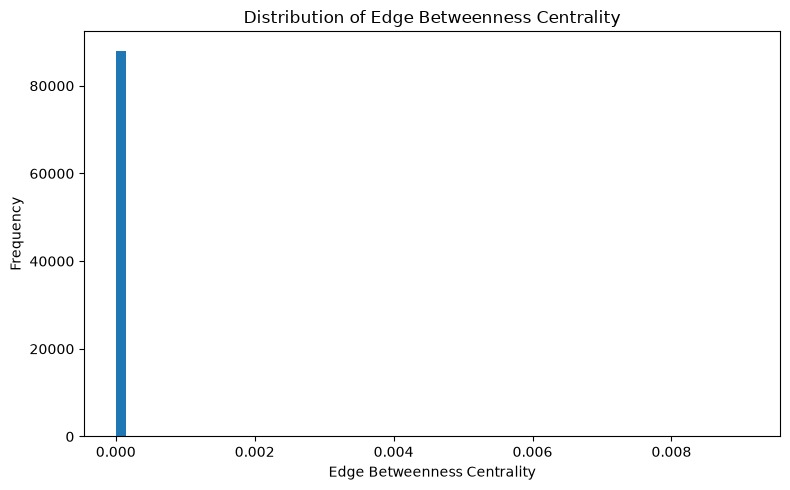

Centrality plot saved to 'outputs/edge_betweenness_histogram.png'

--- Detecting and Comparing Communities ---

Algorithm: Louvain Modularity
Number of Communities: 16
Average Community Size: 252.44
Modularity: 0.8349

Algorithm: Label Propagation
Number of Communities: 44
Average Community Size: 91.80
Modularity: 0.7368


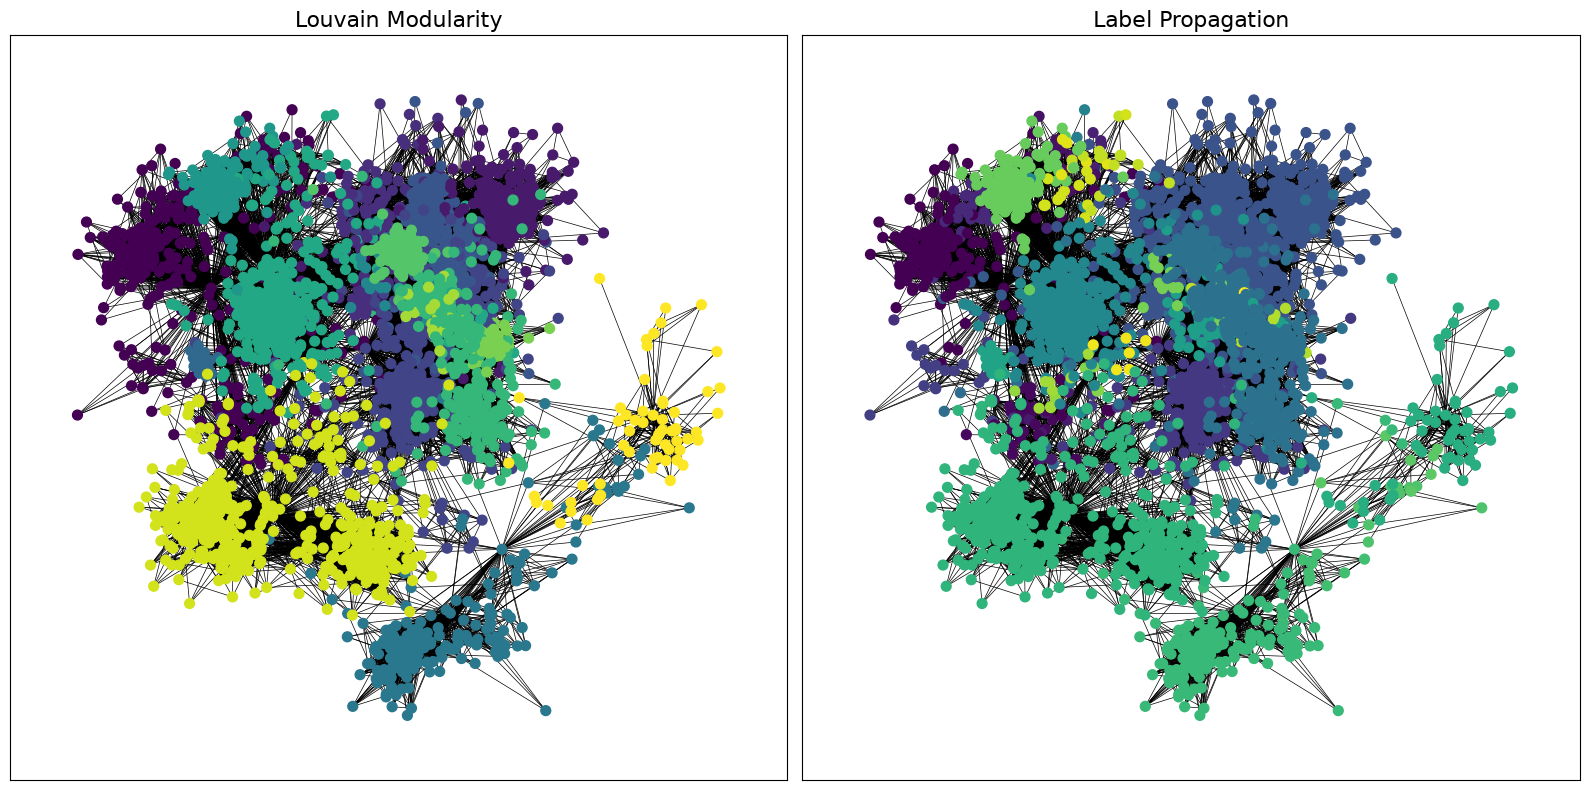


Community visualisations saved to 'outputs/network_visualisations.png'


In [7]:
if __name__ == "__main__":
    main()

### Conclusion
> The analysis reveals a large but sparse social network of 4,039 nodes and 88,234 edges. Despite its low density (0.011), the network is well-connected with an average degree of 43.7. The highly skewed distribution of edge centrality shows that a small fraction of edges act as important bridges within the network. This clustered nature is visually confirmed and quantified by community detection algorithms, which found strong community structures shown by high modularity scores for both Louvain (0.83) and Label Propagation (0.74). While Louvain identified 16 larger communities, Label Propagation divided the network into 44 smaller groups, showing how different algorithms offer different perspectives on the network's social subdivisions.